In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from studies_info import fr_ILAES2025_patients
import an_ilaes_2025 as ilae


https\\www.ilae.org/congresses/36th-international-epilepsy-congress/section/sectionid/2

In [2]:
images_output_path = Path("C:/Users/HFO/Development/pyeeg_toolbox/Images_Output")
FIGSIZE = (16, 8)

(np.float64(-0.5), np.float64(1919.5), np.float64(1045.5), np.float64(-0.5))

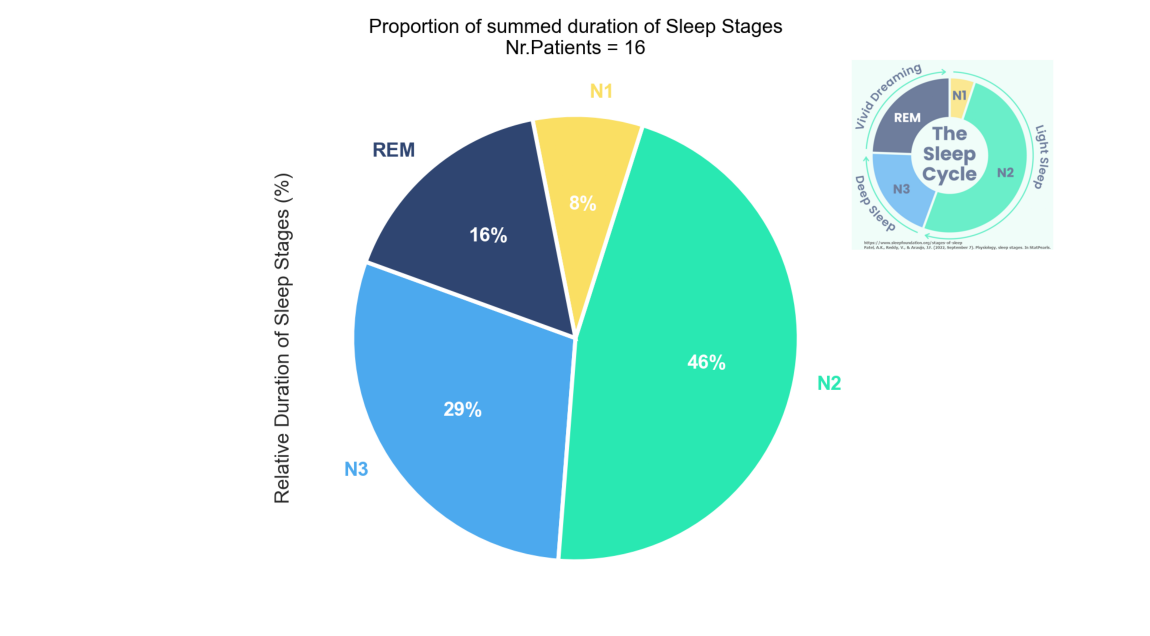

In [3]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
image = plt.imread(images_output_path / "Duration_Of_Sleep_Stages.png")
ax.imshow(image)
ax.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1045.5), np.float64(-0.5))

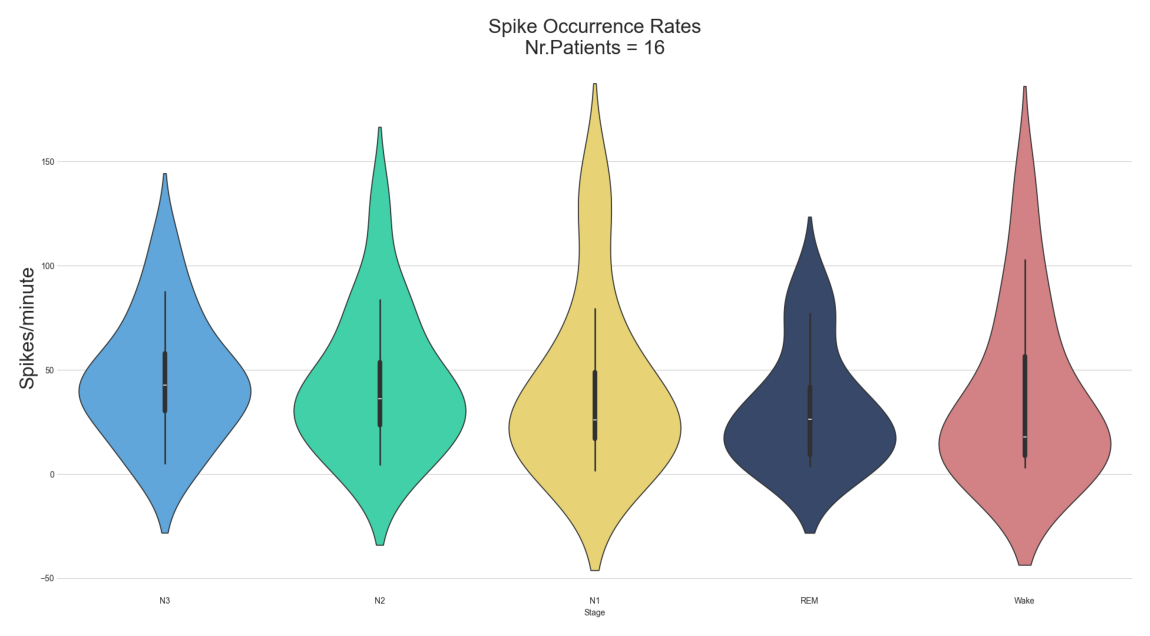

In [4]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
image = plt.imread(images_output_path / "Spike_Occurrence_Rates.png")
ax.imshow(image)
ax.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1045.5), np.float64(-0.5))

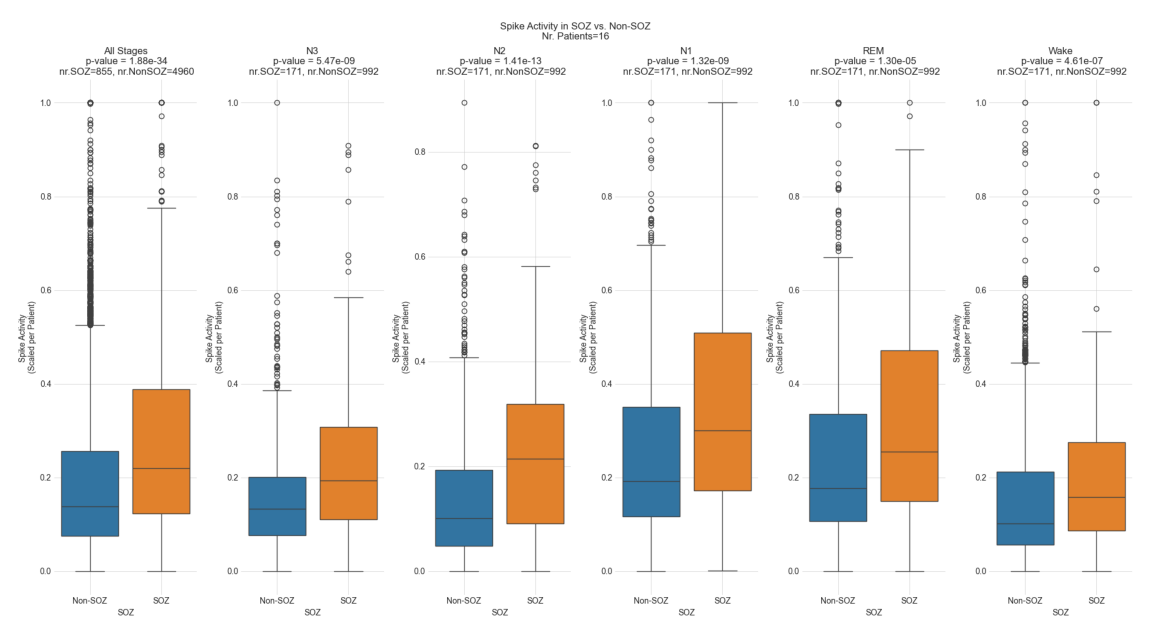

In [5]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
image = plt.imread(images_output_path / "Spike_Activity_SOZ_vs_NonSOZ_Hypothesis_Tests.png")
ax.imshow(image)
ax.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1045.5), np.float64(-0.5))

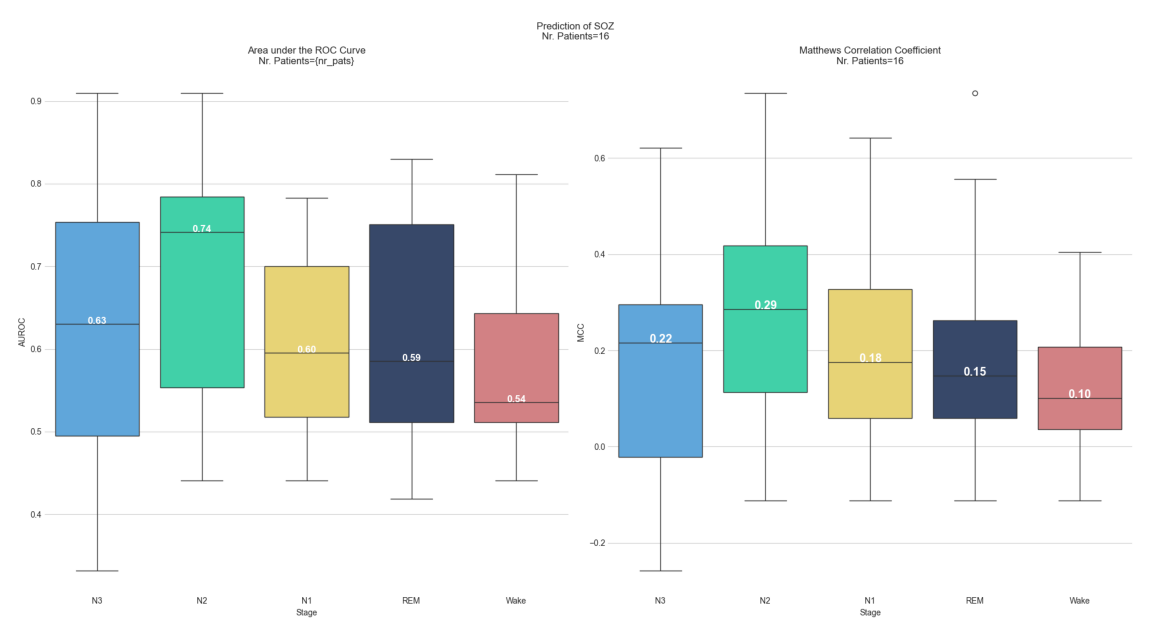

In [6]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
image = plt.imread(images_output_path / "SOZ_Prediction.png")
ax.imshow(image)
ax.axis('off')

(np.float64(-0.5), np.float64(1220.5), np.float64(719.5), np.float64(-0.5))

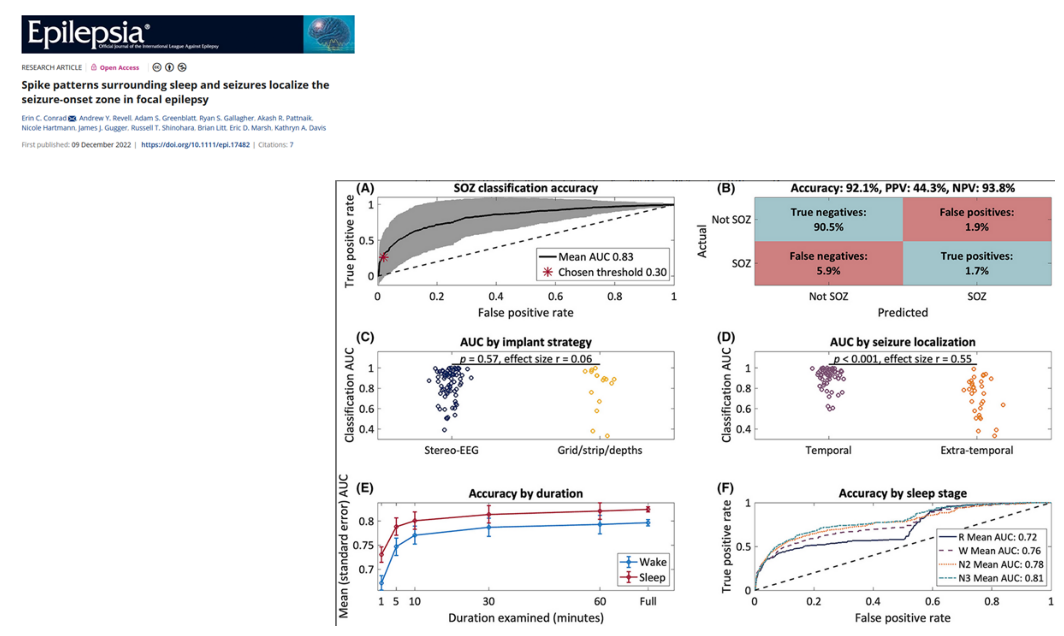

In [7]:
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
image = plt.imread(images_output_path / "Erin_Conrad_Ref_Publication.png")
ax.imshow(image)
ax.axis('off')

# Sleep Stages Duration and Spike rate in each sleep stage

In [8]:
stage_spike_occ_rate_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Stage_Spike_Occurrence_Rate")

pats_ls = [
    "pat_FR_253_StageSpikeOccurrenceRate.csv",
    "pat_FR_970_StageSpikeOccurrenceRate.csv",
    "pat_FR_1084_StageSpikeOccurrenceRate.csv",
    "pat_FR_1096_StageSpikeOccurrenceRate.csv",
    "pat_FR_548_StageSpikeOccurrenceRate.csv",
    "pat_FR_1073_StageSpikeOccurrenceRate.csv",
    "pat_FR_1125_StageSpikeOccurrenceRate.csv",
]

pats_ls = fr_ILAES2025_patients().patients.keys()
pats_ls = [pn+"_StageSpikeOccurrenceRate.csv" for pn in pats_ls]
stage_spike_occ_rate_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Stage_Spike_Occurrence_Rate")


In [9]:
stage_spike_data = pd.DataFrame()
for pdata_fn in pats_ls:
    data_fpath = stage_spike_occ_rate_datapath / pdata_fn
    #print(data_fpath)
    try:
        pdata_df = pd.read_csv(data_fpath)
        stage_spike_data = pd.concat([stage_spike_data, pdata_df])
    except:
        print(f"File {pdata_fn} not found")
#stage_spike_data

Text(0.5, 1.0, 'Nr.Patients = 16')

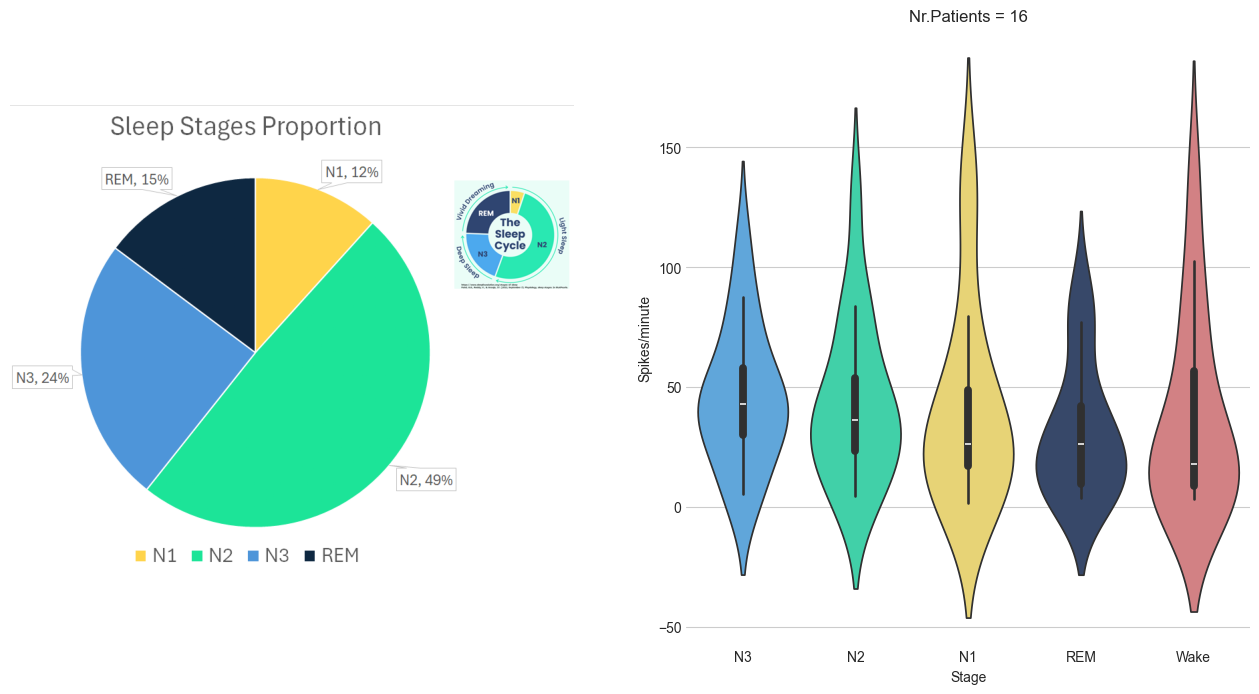

In [10]:
#plt.style.use('seaborn-v0_8-darkgrid')
sns.set_style("whitegrid")
FIGSIZE = (16, 8)
STAGES_COLORS = {'N1':(250,223,99), 'N2':(41,232,178), 'N3':(76,169,238), 'REM':(47,69,113), 'Wake':(224,115,120), 'Unknown':(128,128,128)}

for k,v in STAGES_COLORS.items():
    STAGES_COLORS[k] = (v[0]/255, v[1]/255, v[2]/255)

sleep_stages_duration_fpath = Path("C:\\Users\\HFO\\Documents\\Postdoc_Calgary\\Conferences\\ILAES_2025\\Duration_Of_Sleep_Stages.png")
image = plt.imread(sleep_stages_duration_fpath)

fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
axs[0].imshow(image)
axs[0].axis('off')

nr_pats = len(stage_spike_data.PatID.unique())
sns.violinplot(data=stage_spike_data, x='Stage', y='SpikeOccRate', hue='Stage', palette=STAGES_COLORS, ax=axs[1])
axs[1].set_ylabel("Spikes/minute")
axs[1].set_title(f"Nr.Patients = {nr_pats}")


In [11]:
stage_spike_data[['Stage','SpikeOccRate']].groupby(['Stage']).mean()

,SpikeOccRate
Stage,
N1,41.325159
N2,43.506910
N3,45.732798
REM,31.512690
Wake,37.249795


# Compare SOZ vs Non-SOZ

In [12]:
characterization_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Spike_Characterized_Channels")
pats_ls = [
    "pat_FR_1125_AvgSpikeWdwActivity.csv",
    "pat_FR_253_AvgSpikeWdwActivity.csv",
    "pat_FR_548_AvgSpikeWdwActivity.csv",
    "pat_FR_970_AvgSpikeWdwActivity.csv",
    "pat_FR_1073_AvgSpikeWdwActivity.csv",
    "pat_FR_1084_AvgSpikeWdwActivity.csv",
    "pat_FR_1096_AvgSpikeWdwActivity.csv",
]

pats_ls = fr_ILAES2025_patients().patients.keys()
pats_ls = [pn+"_AvgSpikeWdwActivity.csv" for pn in pats_ls]
stage_spike_occ_rate_datapath = Path("C:\\Users\\HFO\\Development\\pyeeg_toolbox\\Vectorized_WdwAn_Output\\Spike_Characterized_Channels")


In [13]:
spike_data_df = pd.DataFrame()
for pdata_fn in pats_ls:
    try:
        data_fpath = characterization_datapath / pdata_fn
        #print(data_fpath)
        pdata_df = pd.read_csv(data_fpath)
        #pdata_df.Amplitude = stats.zscore(pdata_df.Amplitude)
        pdata_df.Amplitude = MinMaxScaler().fit_transform(pdata_df.Amplitude.values.reshape(-1, 1))
        pdata_df['Patient'] = pdata_fn.replace('_AvgSpikeWdwActivity.csv', '')
        spike_data_df = pd.concat([spike_data_df, pdata_df])
        spike_data_df.loc[spike_data_df.SOZ==1, 'SOZ'] = 'SOZ'
        spike_data_df.loc[spike_data_df.SOZ==0, 'SOZ'] = 'Non-SOZ'
    except Exception as e:
        print(f"File {pdata_fn} not found: {e}")



File pat_FR_253_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_264_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_273_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_384_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_442_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_548_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_565_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_583_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_590_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_862_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_916_AvgSpikeWdwActivity.csv not found: name 'MinMaxScaler' is not defined
File pat_FR_970_AvgSpikeWdwActivity.csv not found: nam

NameError: name 'stats' is not defined

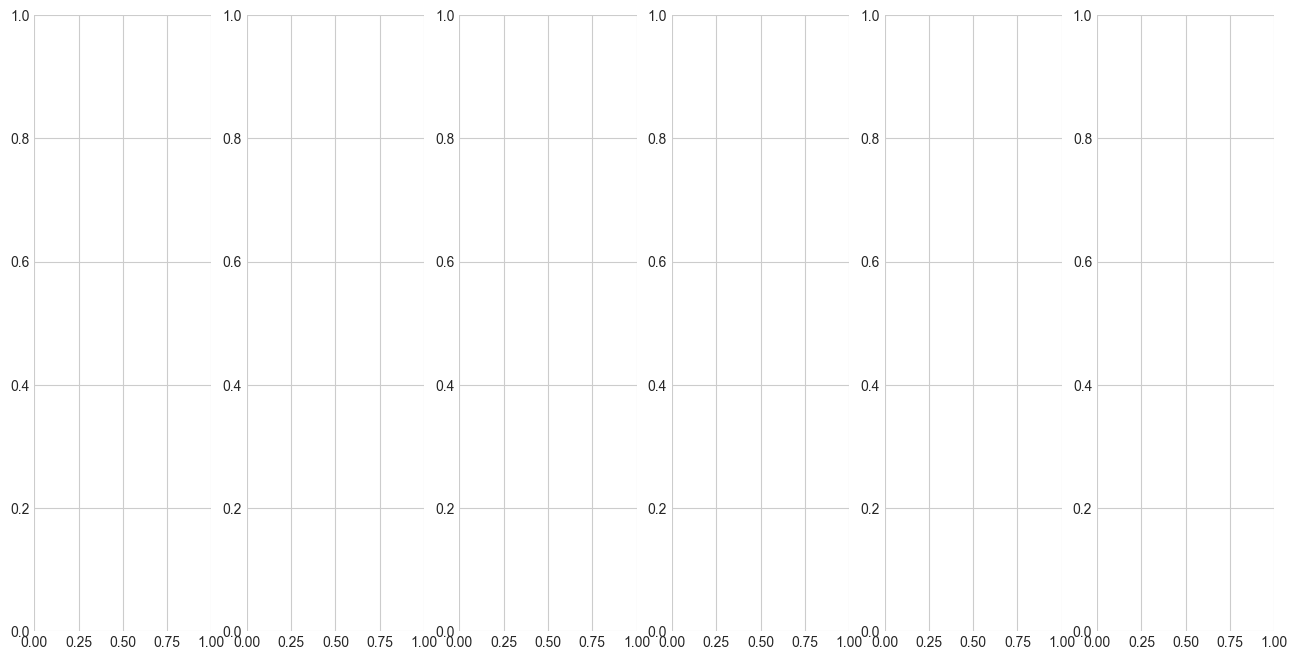

In [14]:
sleep_stages_ls = ['N3', 'N2', 'N1', 'REM', 'Wake']

fig, axs = plt.subplots(1, 6, figsize=FIGSIZE)

# All Stages
plt_ax = axs[0]
res = stats.mannwhitneyu(spike_data_df.Amplitude[spike_data_df.SOZ=='SOZ'], spike_data_df.Amplitude[spike_data_df.SOZ=='Non-SOZ'])
nr_soz = len(spike_data_df[spike_data_df.SOZ=='SOZ'])
nr_non_soz = len(spike_data_df[spike_data_df.SOZ=='Non-SOZ'])

#sns.violinplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
sns.boxplot(data=spike_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=axs[0])
plt_ax.set_title(f"All Stages\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)

# Compare SOZ vs Non-SOZ in the different sleep stages
for si, stage_name in enumerate(sleep_stages_ls):
    plt_ax = axs[si+1]
    stage_data_df = spike_data_df[spike_data_df.Stage==stage_name]

    res = stats.mannwhitneyu(stage_data_df.Amplitude[stage_data_df.SOZ=='SOZ'], stage_data_df.Amplitude[stage_data_df.SOZ=='Non-SOZ'])
    
    nr_soz = len(stage_data_df[stage_data_df.SOZ=='SOZ'])
    nr_non_soz = len(stage_data_df[stage_data_df.SOZ=='Non-SOZ'])
    #sns.violinplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)
    sns.boxplot(data=stage_data_df, x='SOZ', y='Amplitude', hue='SOZ', ax=plt_ax)

    plt_ax.set_title(f"{stage_name}\n p-value = {res.pvalue:.2e}\n nr.SOZ={nr_soz}, nr.NonSOZ={nr_non_soz}")
    plt_ax.set_ylabel("Spike Activity \n(Scaled per Patient)")
    plt_ax.grid(color='0.8', linestyle='-', linewidth=0.5)


plt.get_current_fig_manager().full_screen_toggle()
plt.suptitle(f"Spike Activity in SOZ vs. Non-SOZ")
plt.tight_layout()

# Predict SOZ with LogReg

In [ ]:
def oversample_patients(train_set_df):
    os_train_set_df = pd.DataFrame()
    for pat_id in train_set_df.Patient.unique():
        pat_df = train_set_df[train_set_df.Patient==pat_id]
        soz_df = pat_df[pat_df.SOZ=='SOZ']
        non_soz_df = pat_df[pat_df.SOZ=='Non-SOZ']
        n_p_ratio = int(np.round(len(non_soz_df)/len(soz_df)))+1
        if n_p_ratio>=2:
            soz_df = pd.concat([soz_df]*n_p_ratio)
        os_train_set_df = pd.concat([os_train_set_df, soz_df, non_soz_df])
    os_train_set_df = os_train_set_df.sample(frac=1).reset_index(drop=True)
    return os_train_set_df

In [ ]:
# Predict SOZ based on Spike Activity
prediction_results = {'Stage':[], 'Metric':[], 'Value':[]}
for si, stage_name in enumerate(sleep_stages_ls):
    stage_data_df = spike_data_df[spike_data_df.Stage==stage_name]
    for pat_id in stage_data_df.Patient.unique():
        train_set_df = stage_data_df[stage_data_df.Patient!=pat_id]
        test_set_df = stage_data_df[stage_data_df.Patient==pat_id]

        # scaler = StandardScaler()
        # train_set_df.Amplitude = scaler.fit_transform(train_set_df.Amplitude.values.reshape(-1, 1))
        # test_set_df.Amplitude = scaler.transform(test_set_df.Amplitude.values.reshape(-1, 1))

        # Oversample to have equal positives and negatives
        #train_set_df = oversample_patients(train_set_df)

        X_train = train_set_df.Amplitude.to_numpy().reshape(-1, 1)
        y_train = train_set_df.SOZ.to_numpy()=='SOZ'
        #print(f"Positives to Negatives Ratio:{np.sum(y_train)/len(y_train)*100}")
        
        X_test = test_set_df.Amplitude.to_numpy().reshape(-1, 1)
        y_test = test_set_df.SOZ.to_numpy()=='SOZ'

        # Basic feature engineering
        # X_train = np.hstack([X_train, X_train**2, X_train**3])
        # X_test = np.hstack([X_test, X_test**2, X_test**3])

        model = LogisticRegression(penalty='l2', class_weight='balanced', solver='liblinear', max_iter=1000, tol=0.1)
        model.fit(X_train, y_train)
        y_predicted = model.predict(X_test)

        # model = KNeighborsClassifier(n_neighbors=int(np.sum(y_train)*0.25))
        # model.fit(X_train, y_train)
        # y_predicted = model.predict(X_test)

        # model = SVC()
        # model.fit(X_train, y_train)
        # y_predicted = model.predict(X_test)

        print("Training Set", len(y_test))

        #model = SVC(random_state=42).fit(X_train, y_train)
        #y_predicted = model.predict(X_test) 

        auroc_val = roc_auc_score(y_test, y_predicted)
        mcc_val = matthews_corrcoef(y_test, y_predicted)
        prediction_results['Stage'].append(stage_name)
        prediction_results['Metric'].append('AUROC')
        prediction_results['Value'].append(auroc_val)
        prediction_results['Stage'].append(stage_name)
        prediction_results['Metric'].append('MCC')
        prediction_results['Value'].append(mcc_val)

prediction_results_df = pd.DataFrame(prediction_results)

In [ ]:
for sleep_stage in sleep_stages_ls:
    auroc_vals = prediction_results_df[np.logical_and(prediction_results_df.Metric=='AUROC', prediction_results_df.Stage==sleep_stage)].Value.to_numpy()
    q75, q25 = np.percentile(auroc_vals, [75 ,25])
    iqr = q75 - q25
    print(f"Stage: {sleep_stage}, AUROC_IQR: {iqr:.2f}")
    pass

print('\n\nMedian AUROC')
print(prediction_results_df[prediction_results_df.Metric=='AUROC'][['Stage', 'Value']].groupby(['Stage']).median())
print('\n\nStd_AUROC')
print(prediction_results_df[prediction_results_df.Metric=='AUROC'][['Stage', 'Value']].groupby(['Stage']).std())

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=FIGSIZE)
box_plot = sns.boxplot(data=prediction_results_df[prediction_results_df.Metric=='AUROC'], x='Stage', y='Value', hue='Stage', palette=STAGES_COLORS, ax=axs[0])
axs[0].set_title("Area under the ROC Curve")
axs[0].set_ylabel("AUROC")
medians_df = prediction_results_df[prediction_results_df.Metric=='AUROC'][['Stage', 'Value']].groupby(['Stage']).median().reset_index()
vertical_offset = prediction_results_df[prediction_results_df.Metric=='AUROC'].Value.median() * 0.05 # offset from median for display
for xtick in box_plot.get_xticks():
    median_val = medians_df.Value[medians_df.Stage==sleep_stages_ls[xtick]].to_numpy()[0]
    median_str = f"{median_val:.2f}"
    box_plot.text(x= xtick, y=median_val, s=median_str, horizontalalignment='center',size='large',color='w',weight='semibold')
    pass

box_plot = sns.boxplot(data=prediction_results_df[prediction_results_df.Metric=='MCC'], x='Stage', y='Value', hue='Stage', palette=STAGES_COLORS, ax=axs[1])
axs[1].set_title("Matthews Correlation Coefficient")
axs[1].set_ylabel("MCC")
medians_df = prediction_results_df[prediction_results_df.Metric=='MCC'][['Stage', 'Value']].groupby(['Stage']).median().reset_index()
vertical_offset = prediction_results_df[prediction_results_df.Metric=='MCC'].Value.median() * 0.05 # offset from median for display
for xtick in box_plot.get_xticks():
    median_val = medians_df.Value[medians_df.Stage==sleep_stages_ls[xtick]].to_numpy()[0]
    median_str = f"{median_val:.2f}"
    box_plot.text(x= xtick, y=median_val, s=median_str, horizontalalignment='center',size='x-large',color='w',weight='semibold')
    pass